# Illustrative Figures for Introduction
### Connor van Wieren, 2025

In [1]:
from datetime import datetime
from IPython.display import display, Markdown
todays_date = str(datetime.now())[:16] # lim  it to minutes
display(Markdown(f'### Date: {todays_date}'))

### Date: 2025-04-10 12:11

**Figures:**
1. 

## Imports

**Model source:** this notebook imports the tracer-advection/diffusion sediment transport model from [TracerDiff](https://github.com/VanWieren/TracerDiff), the actively maintained, installable package version of the model used in this paper (van Wieren et al., 2026, EPSL, https://doi.org/10.1016/j.epsl.2025.119745). Install it first with:

```bash
git clone https://github.com/VanWieren/TracerDiff.git
cd TracerDiff
pip install -e .
```

In [9]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
#from pypalettes import load_cmap # for color palettes
import jax
import jax.numpy as jnp
from jax import  jit, random, lax, vmap
from jax.scipy.integrate import trapezoid as trapz
jax.config.update('jax_platform_name', 'cpu')
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from cycler import cycler
import seaborn as sns
import pandas as pd 
import time
import os
from scipy import signal
from scipy.stats import norm, uniform, gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import rasterio
import pickle
import dill
import sys
import string

matplotlib.rcParams['pdf.fonttype'] = 42  # for acrobat? idk why i need this

# load the TracerDiff model (https://github.com/VanWieren/TracerDiff)
# install locally with: pip install -e /path/to/TracerDiff  (see the TracerDiff README for full instructions)
from tracerdiff import run, Model_output
from tracerdiff.utils import *

sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport')
from bahamas import load_geyman_bahamas

# import facies
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/notebooks/')
from facies import facies

# interactive plots
from ipywidgets import interactive, interact
from IPython.display import clear_output, Video

np.set_printoptions(threshold=np.inf,linewidth=np.inf)

fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/figures/'
sem_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Talks/UVic_Department_Talks/Exit Seminar/img/model/' # for exit seminar
tex_fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Publications/Ch2_Paleozoic_CIE_EPSL/img/'
data = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/data/'
## load geyman bahamas facies data
#subset_land, subset_ms, subset_ws, subset_ps, subset_ogs, subset_sgs = load_geyman_bahamas(downsample=5000,plot=False)
plt.style.use(light_style)

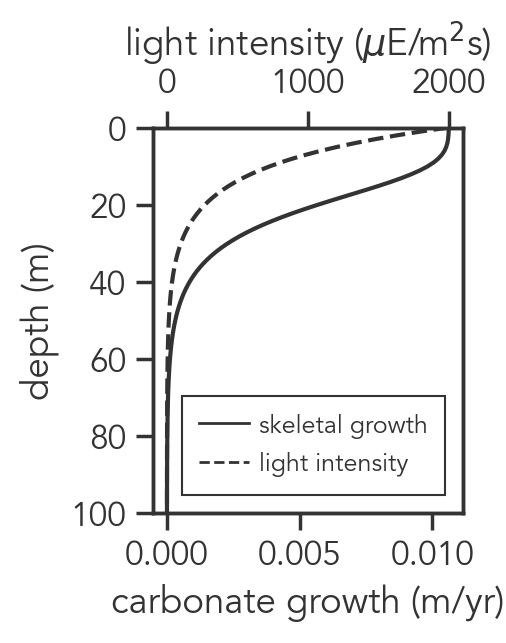

In [13]:
z = np.linspace(0,100,100) # depth (m) , positive downwards
Dt_alg = 0
Dt_pel = 0.5

Iz,G = bosscher_G(z,Gm=0.00125,out='both',Dt=Dt_alg)
# pelagic_growth = lambda x: bosscher_G(x,Io=0.00125,k=0.1,out='light',Dt=Dt_pel)  # here G is light curve scaled to Gmax which is 0.00125 here (for pelagic), np.trapz to max depth
G = G*8.5

# plot
fig,ax = plt.subplots(figsize=(2,2.5))
ax.plot(Iz,z,color='.2',ls='--',label='light intensity')
axi = ax.twiny()
axi.plot(G,z,color='.2',ls='-',label='skeletal growth')
ax.invert_yaxis()
ax.set_ylabel('depth (m)')
ax.xaxis.set_ticks_position('top')  # Move ticks to the top
ax.xaxis.set_label_position('top')  # Move label to the top
axi.xaxis.set_ticks_position('bottom')  # Move ticks to the top
axi.xaxis.set_label_position('bottom')  # Move label to the top
ax.set_xlabel(r'light intensity ($\mu$E/m$^2$s)')
axi.set_xlabel('carbonate growth (m/yr)')
ax.set_ylim(100,0);
#axi.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# make legend
el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='.2', ls='-',label='skeletal growth',markerfacecolor='none', markersize=0,),
      Line2D([0], [0],mew=0.65,lw=1, marker='v', color='.2', ls='--',label='light intensity',markerfacecolor='none', markersize=0)]

leg_main = ax.legend(handles=el,loc=4,ncols=1,frameon=True,framealpha=1,fontsize=9,handletextpad=0.4,markerfirst=True,borderaxespad=1)
frame = leg_main.get_frame()
frame.set_edgecolor('.2')
frame.set_linewidth(.75)
frame.set_boxstyle('square')

fig.savefig(tex_fig_dir+'carb.pdf',format='pdf',bbox_inches='tight',transparent=False)

### Version for exit seminar

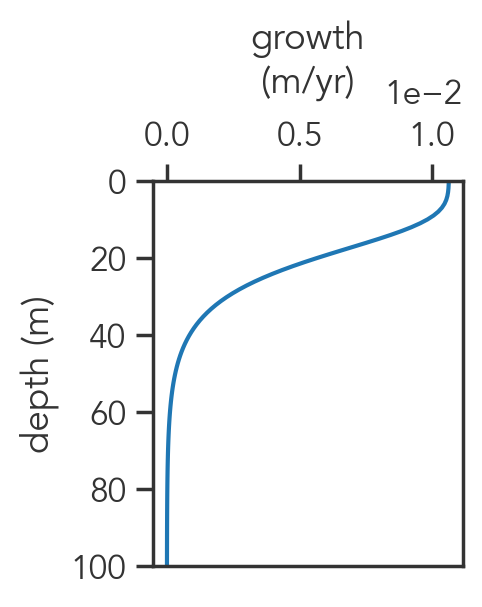

In [5]:
z = np.linspace(0,100,100) # depth (m) , positive downwards
Dt_alg = 0
Dt_pel = 0.5

Iz,G = bosscher_G(z,Gm=0.00125,out='both',Dt=Dt_alg)
# pelagic_growth = lambda x: bosscher_G(x,Io=0.00125,k=0.1,out='light',Dt=Dt_pel)  # here G is light curve scaled to Gmax which is 0.00125 here (for pelagic), np.trapz to max depth
G = G*8.5

# plot
fig,ax = plt.subplots(figsize=(2,2.5))
ax.plot(G,z,color='tab:blue',ls='-',label='skeletal growth')
ax.invert_yaxis()
ax.set_ylabel('depth (m)')
ax.xaxis.set_ticks_position('top')  # Move ticks to the top
ax.xaxis.set_label_position('top')  # Move label to the top
ax.set_xlabel('growth\n(m/yr)',labelpad=10)
ax.set_ylim(100,0);
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

fig.savefig(sem_dir+'bosch.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

# Simple Transgression Model for Figures

gradient difference =  4.638793
max = 5.95; min = 1.31


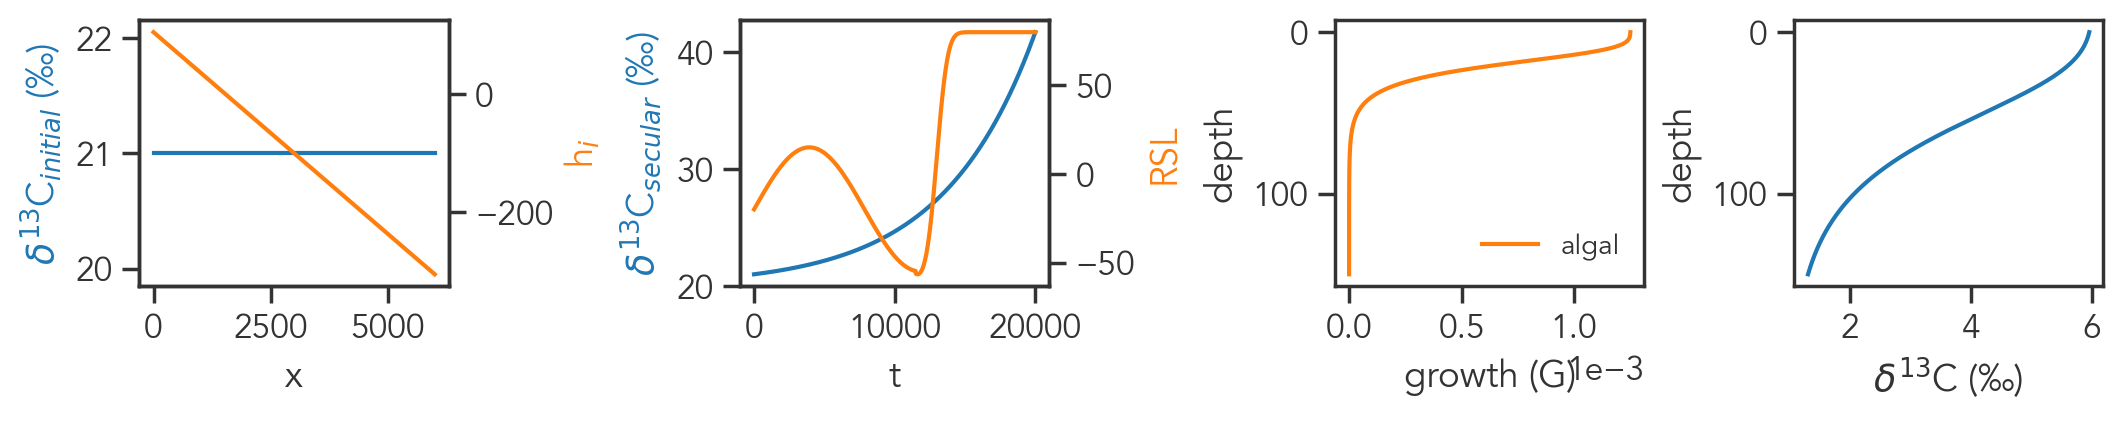

In [6]:
# from the current method
params = {'Nx':400,        # was 200; 400
          'xmin':0,
          'xmax':6000,     # was 180, scaled up, just need to change slope of hi
          'dx':0.8, #'none',     # 0.1 # if none defaults to (xmax-xmin)/(Nx); 0.8
          'start':0,
          'dt':0.1,
          'total_n':2000,
          'compiled_steps':100,
          'pel_epsilon':0,   # ‰; 1.5
          'alg_epsilon':0,
          'coral_epsilon':0,
          'ocean_depth':0,  # depth at which seawater reflects open ocean
          'marine_K':2.5e-1,   # 1e-2; 1.5e-1; 2.5e-1, 2.5e-3 dropped by order of mag to test boundary conditions (not diffusing near to bounds)
          'land_K':5e-1,   # 2e-2; 2.5e-1' 5e-1
          'smooth_K':6,      # was 10; the lower it is the more of a sharp step function it is
          'grid_ylen':500,       # 10000; I really don't think it needs to be this big
          'base_depth':10,       # bottom n meters averaged for reaction-curve lower bound (matches shuram_TOC_public convention)
          'A':0.1}             # 0.01 0.1, I think needs to be smaller to scale with small magnitude of this run's topography changes
                             # A needs to be tuned. If A too big or too small, model provides unrealistic or incorrect functionality
# build time and space constraints for initial condition setting and initiation functions (sl, growth, etc.)
x,t,end = init_vars(params)

# setup
z = np.linspace(1e-5,150,1000)
G_base = 1 # minumum (deep) value; 1
Gm = 5    # maximum (shallow) value; 5
depth_w_fun = lambda x: bosscher_G(x,out='growth',Gm=Gm,G_base=G_base,k=0.025,Ik=750) # can change k for how sharp the gradient is (lower = more gradual); 0.2. 0.4
#depth_w_fun = lambda x: -x/25+6 # simple linear
#depth_w_fun = lambda x: jnp.ones_like(x) * 5  # constant isotopic value
maxw = max(depth_w_fun(z))
minw = min(depth_w_fun(z))

# secular w array
#sec_w_fun = lambda t: jnp.zeros_like(t)
sec_w_fun = lambda t: jnp.exp(t/6500)+20
sec_w_i = sec_w_fun(t)[0]

## Define h: initial topographic composition
hi = -0.0685*x+105 # for xmax of 6000; slope chosen to match bahamas aspect ratio

## Define w: initial proxy composition
rsl = 21 #max(hi)
depth = rsl - hi
#wi = depth_w_fun(depth)
#wi = wi.at[:82].set(maxw)
wi = jnp.ones_like(hi) * sec_w_i # shallow value boundary condition for positive run
#wi = jnp.ones_like(hi) * maxw 
#wi = jnp.ones_like(hi) * 0
#wi = wi.at[0].set(maxw)
#wi = wi.at[-1].set(minw)


#wi = wi.at[200:].set(1)
#wi = depth_w_fun(sl_fun(0) - hi)

# sea level curve array - want to simulate a range of magnitudes (HICE is inferred to be ~150m)
sl_funa = lambda t: 35*jnp.sin((t)/2500)-20 # simple version # 1400

slta = np.zeros_like(t)
slta[0:375] = 35 # 375
#slta[0:750] = 65
slta[375:1050] = 0 # 750:1050
slta[1050:1300] = -60 # min(sl_funa(t)) # 1300
slta[1300:] = 80 # 130, 150
slta = gaussian_filter(slta,sigma=60) # apply convolution 60, 40
sl_funb = lambda x: jnp.interp(x,jnp.linspace(0,end,slta.size),slta) # interpolate so works with JAX

sl_fun = lambda t: jnp.where(t<=11500,sl_funa(t),sl_funb(t))
#sl_fun = lambda t: 0.005*t-50 # even simpler distinct prograding with lower sea level
#sl_fun = lambda t: jnp.ones_like(t)*21
#sl_fun = lambda t: jnp.ones_like(t)*-50#jnp.max(hi) # for testing

fig,ax = plt.subplots(1,4,figsize=(10.5,2),layout='constrained')

# initial proxy and topography
ax[0].plot(x,wi,label='$\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
axi = ax[0].twinx()
axi.plot(x,hi,label='h$_i$',color='tab:orange') # showing index not actual units
ax[0].set_xlabel('x')
ax[0].set_ylabel('$\delta^{13}$C$_{initial}$ (‰)',color='tab:blue')
axi.set_ylabel('h$_i$',color='tab:orange')

# proxy over time
ax[1].plot(t,sec_w_fun(t),color='tab:blue')
ax[1].set_ylabel('$\delta^{13}$C$_{secular}$ (‰)',color='tab:blue')
ax[1].set_xlabel('t');
axii = ax[1].twinx()
# sea level
axii.plot(t,sl_fun(t),color='tab:orange')
axii.set_ylabel('RSL',color='tab:orange')

## Growth Functions ##
algal_growth = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=0)

# pelagic growth
ax[2].plot(algal_growth(z),z,color='tab:orange',label='algal',ls='-')
ax[2].set_xlabel('growth (G)')
ax[2].legend(frameon=False)
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].set_ylabel('depth')
ax[2].invert_yaxis()

ax[3].plot(depth_w_fun(z),z)
ax[3].invert_yaxis()
ax[3].set_xlabel('$\delta^{13}$C (‰)')
ax[3].set_ylabel('depth')
#ax[3].set_xticks(np.arange(G_base,Gm+2));
print('gradient difference = ',max(depth_w_fun(z))-min(depth_w_fun(z)))
print(f'max = {max(depth_w_fun(z)):.2f}; min = {min(depth_w_fun(z)):.2f}')

calculated ymin,ymax = -386.00, 185.00
mean grid dy = 1.144e+00


running model: simple_transgression_A0.1_ylen500_2025-03-29 10:35:   0%|          | 0/2000 [00:00<?, ? compile…

plotting results:   0%|          | 0/2000 [00:00<?, ? beds/s]

actual ymin,ymax = -306.00, 105.00


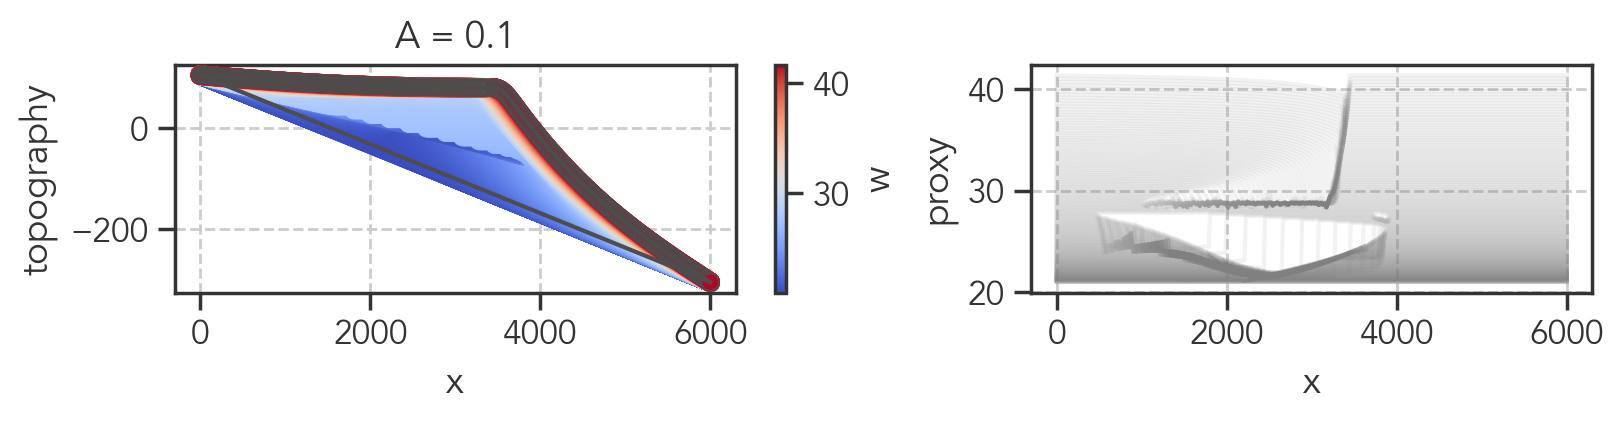

In [7]:
# name of model
desc = 'simple_transgression' 

params['alg_coef'] = 8.5  # moved from run() kwarg -- alg_coef belongs in params, not run()

mod = run(params,                            
          model_desc = desc,                
          hi = hi,                            
          wi = wi,                            
          sl_fun = sl_fun,                   
          sec_w_fun = sec_w_fun,           
          wi_sec = True,
          depth_w_fun = None,#depth_w_fun,         
          growth_fun_alg = algal_growth,     
          plot_skip = 10,                    
          plot_out = True,
          const_K = False,                   
          w_set_erode = True,              
          full_storage = False,              
          figsize = (8,2),
          no_res_bounds = False,
          normalize_balance = True)

max depth = 411.00


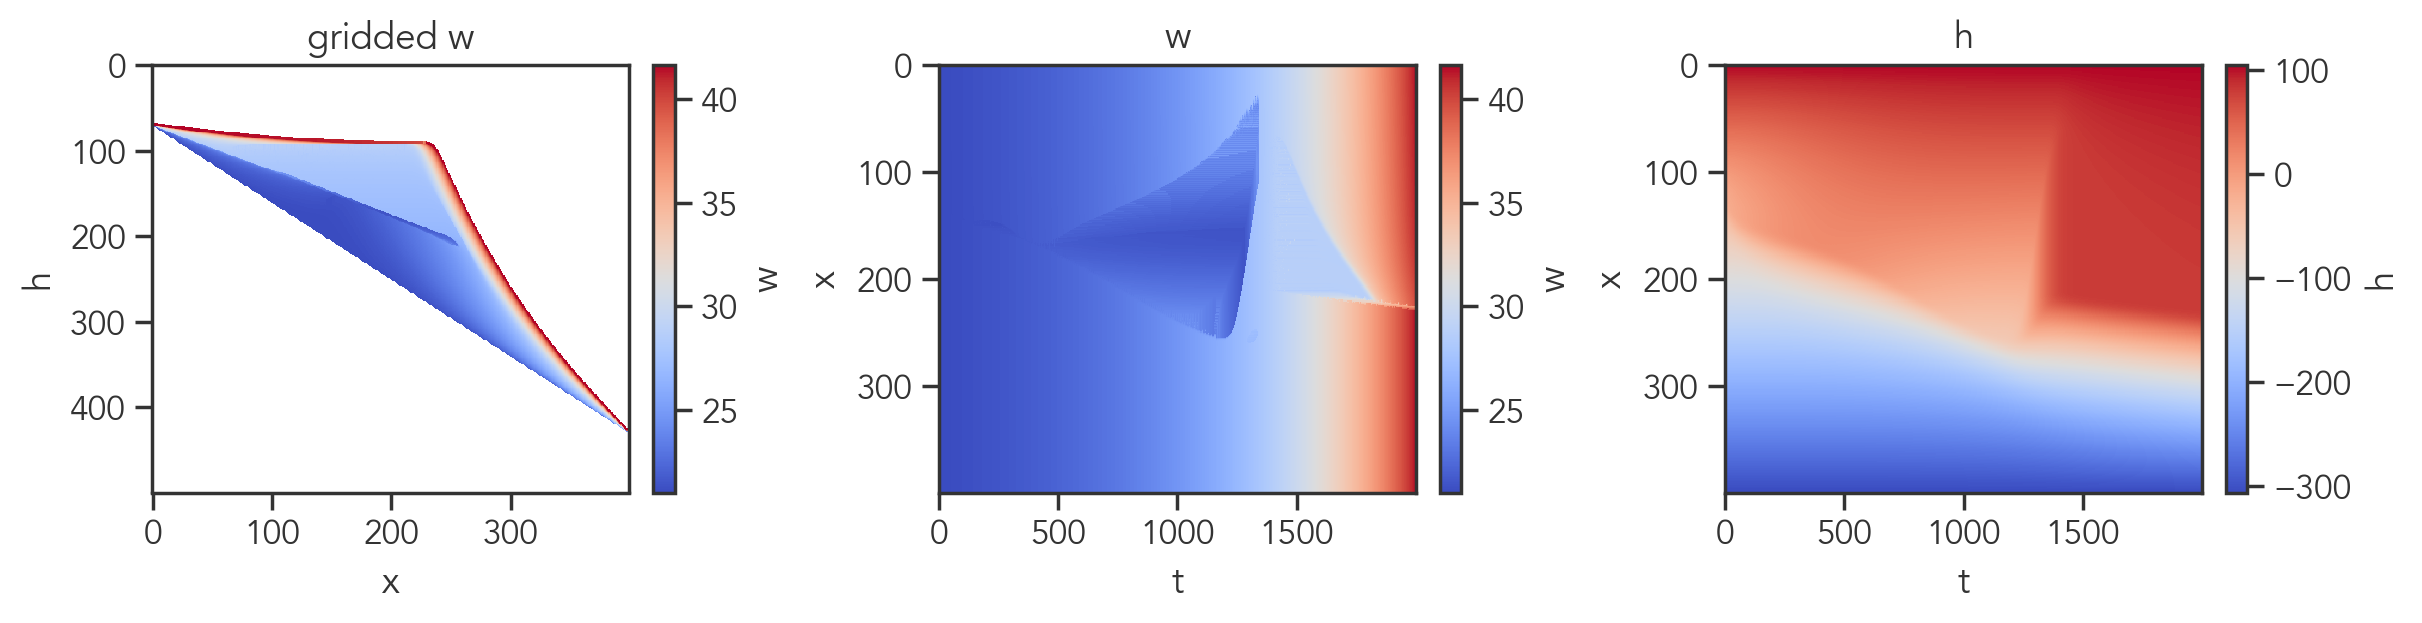

In [8]:
max_depth = np.nanmax(mod['ds'])
# simple version with fewer facies and just depth ranges
facies_data = facies(max_depth)

# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette


# define max depthD
max_depth = np.nanmax(mod['ds'])
print(f'max depth = {max_depth:.2f}')
## model outputs|
out = Model_output(**mod,facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
out.plot_grids()

## Figure for demonstrating facies gridding approach

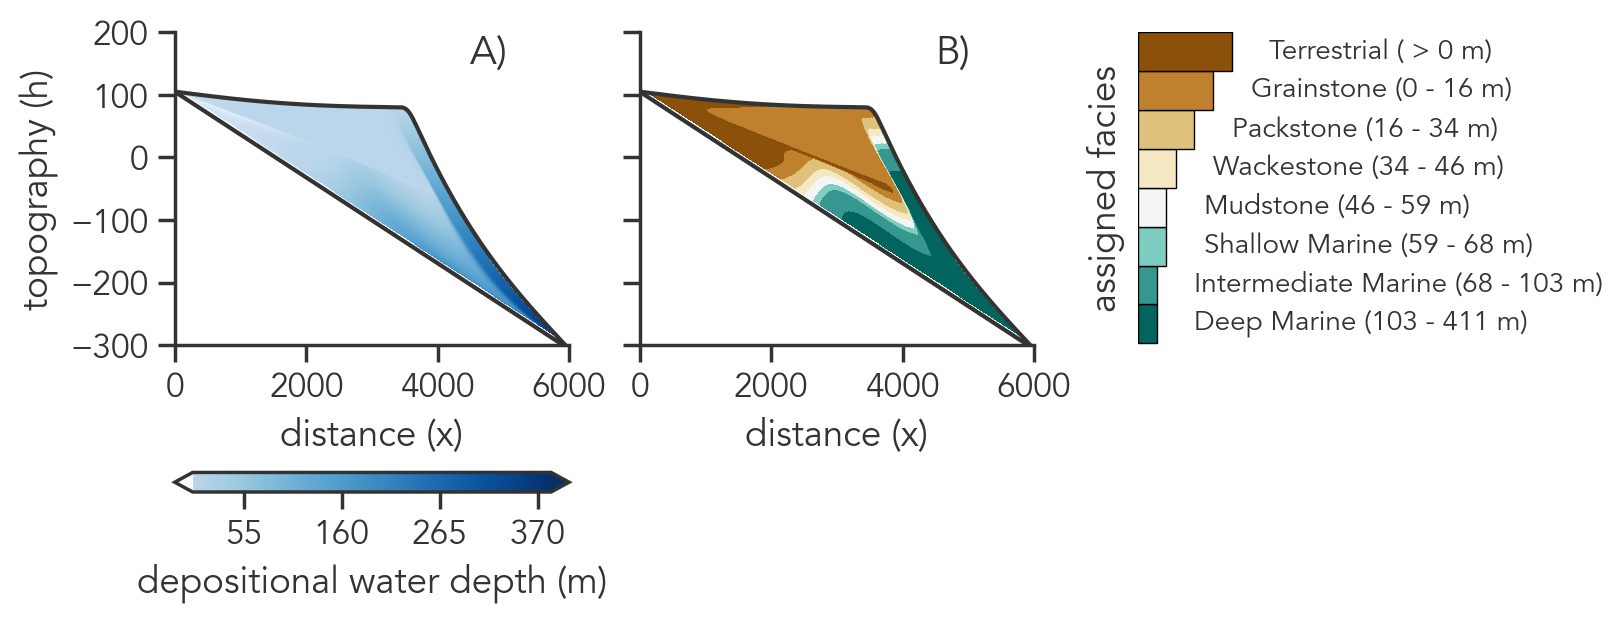

In [21]:
fig,ax = plt.subplot_mosaic(
    """
    abc
    abc
    d..
    """,figsize=(8,3),width_ratios=[1,1,.25],height_ratios=[1,1,.125],layout='constrained')

# depth
imd = ax['a'].imshow(out.im_d,aspect='auto',origin='lower',interpolation='gaussian',cmap='Blues',extent=out.extent,rasterized=True)
cbar = plt.colorbar(imd,cax=ax['d'],orientation='horizontal',location='bottom',label='depositional water depth (m)',extend='both')
cbar.ax.set_xticks(np.arange(int(np.nanmin(out.im_d.ravel())),int(np.ceil(np.nanmax(out.im_d.ravel()))),105))
cbar.ax.set_xlim(left=0)

# facies
imf = ax['b'].imshow(out.facies_pred,aspect='auto',origin='lower',interpolation='gaussian',cmap=out.cmap,extent=out.extent,rasterized=True)
#tick_locs = center_ticks(out.facies_colours) # set ticks to center of each colourbar box, going to last one because colour bar has length with land, need one less
#cbar = plt.colorbar(imf,cax=ax['e'],orientation='horizontal',location='bottom',label='assigned facies',ticks=tick_locs)
#cbar.ax.set_xticklabels(out.labels,rotation=45)

# legend
flab,dlab = out.facies_legend(ax=ax['c'],offset=0.4,aspect=False,label_right=True,lab_size=10,label='both')
ax['c'].axis('on')
ax['c'].set_yticks([])
ax['c'].set_xticks([])
ax['c'].spines[['bottom','left']].set_visible(False)

# format
ax['b'].sharey(ax['a'])
ax['a'].set_ylabel('topography (h)')
ax['b'].tick_params(axis='y', labelleft=False)
ax['c'].set_ylabel('assigned facies')

for i in ['a','b']:
    ax[i].plot(out.x,out.beds_eroded[0],color='.2',zorder=1000,lw=1.5)
    ax[i].plot(out.x,out.beds_eroded[-1],color='.2',zorder=1000,lw=1.5)
    ax[i].spines[['top','right']].set_visible(False)
    #ax[i].set_xticks([])
    ax[i].set_ylim(-300,150)
    ax[i].set_xlabel('distance (x)')
    ax[i].set_yticks(np.arange(-300,300,100))

abc = ['A','B']
for i,a in zip(['a','b'],abc):
    ax[i].text(0.75,0.9,f'{a})',transform=ax[i].transAxes,fontsize=14)
    
fig.savefig(tex_fig_dir+'facies_bin.pdf',format='pdf',dpi=300,bbox_inches='tight',transparent=False)

## Figure showing variable K

In [22]:
marine_K = params['marine_K']
land_K = params['land_K']

lims = (1,1999,1)

@interact(tidx=lims)
def f(tidx):
    #tidx = 1800
    h_half = out.beds[tidx]
    sea_level = out.rsl_strat[tidx]
    gamma = params['smooth_K']
    K = ((-1*np.tanh((h_half-sea_level)*1/gamma)*(marine_K-land_K)/2)+(land_K+marine_K)/2)
    print(f'gamma = {gamma}')
    
    fig,ax = plt.subplots(figsize=(4.5,4))
    ax.grid()
    
    ax.plot(out.x,K)
    axi = ax.twinx()
    axi.plot(out.x,h_half,color='tab:orange')
    axi.axhline(sea_level,color='grey',ls='--')


interactive(children=(IntSlider(value=1000, description='tidx', max=1999, min=1), Output()), _dom_classes=('wi…

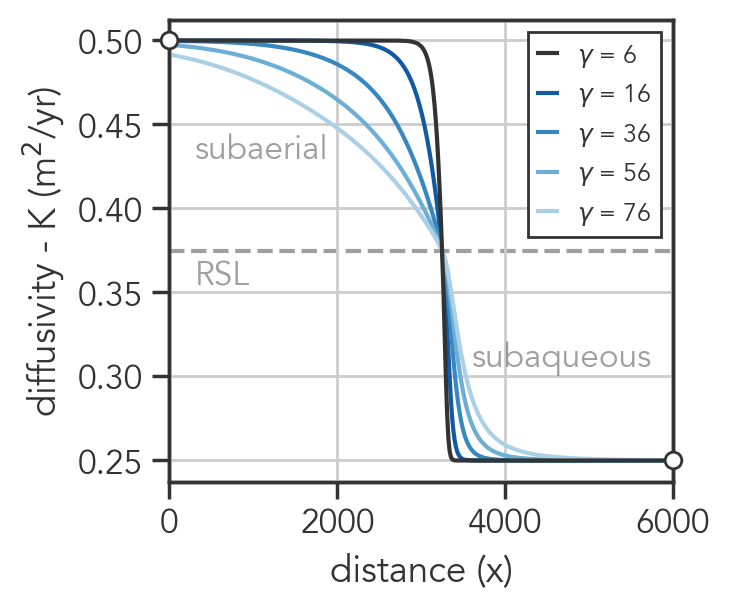

In [30]:
marine_K = params['marine_K']
land_K = params['land_K']

tidx = 807
h_half = out.beds[tidx]
sea_level = out.rsl_strat[tidx]

gamma_init = params['smooth_K']
K_init = ((-1*np.tanh((h_half-sea_level)*1/gamma_init)*(marine_K-land_K)/2)+(land_K+marine_K)/2)
#print(f'gamma = {gamma_init}')

fig,ax = plt.subplots(figsize=(3.25,3))

# plot first one - current used in model
#ax.plot(out.x,K_init,color='k',ls='-',zorder=1000,label=f'$\gamma_{{mod}}$ = {gamma_init}')
ax.plot(out.x,K_init,color='.2',ls='-',zorder=1000,label=f'$\gamma$ = {gamma_init}')


# loop over gammas
gamma = np.arange(gamma_init,80,10) #params['smooth_K']; # currently 6
skip=2

# blues
a = sns.color_palette('Blues_r',n_colors=int(len(gamma)/skip)+1)

# greens
# a = sns.color_palette('GnBu_r',n_colors=int(len(gamma)/skip)+1).as_hex()
# a[-1] = 'tab:green'
# a = sns.color_palette(a)

ax.set_prop_cycle(cycler('color',a))

for i,g in enumerate(gamma[1:]):
    if i%skip==0:
        K = ((-1*np.tanh((h_half-sea_level)*1/g)*(marine_K-land_K)/2)+(land_K+marine_K)/2)
        ax.plot(out.x,K,label=f'$\gamma$ = {g}')

ax.legend(fontsize=9,handlelength=0.75)

# add rsl for demo
axi = ax.twinx()
axi.axhline(sea_level,ls='--',color='tab:grey',zorder=1000,alpha=0.75)
#axi.set_zorder(10)
ax.set_zorder(50)
ax.set_facecolor('none')
axi.text(0.05,0.425,'RSL',fontsize=12,transform=axi.transAxes,color='tab:grey',alpha=0.75)
#axi.tick_params(axis='y', colors='tab:grey')   
#axi.spines['right'].set_color('tab:grey')
#ax.spines['right'].set_visible(False)
axi.set_yticks([])

# scatter points
ax.scatter(0,land_K,zorder=1000000,edgecolor='.2',facecolor='w',label='subaerial K',clip_on=False)
ax.scatter(6000,marine_K,zorder=1000000,edgecolor='.2',label='subaqueous K',facecolor='w',clip_on=False)

# label environments
ax.text(0.05,0.7,'subaerial',fontsize=12,transform=axi.transAxes,color='tab:grey',alpha=0.75)
ax.text(0.6,0.25,'subaqueous',fontsize=12,transform=axi.transAxes,color='tab:grey',alpha=0.75)

# format
#axi.set_ylabel('sea level (m)',color='tab:grey')
ax.grid(ls='-',zorder=0)
ax.set_xlabel('distance (x)')
ax.set_ylabel('diffusivity - K (m$^2$/yr)')

# set lims
ax.set_xlim(0,6000)
#ax.set_ylim(0.25,0.5)

# save figure
fig.savefig(tex_fig_dir+'variable_K.pdf',format='pdf',dpi=300,bbox_inches='tight',transparent=False)